# Setup
In colab:

Go to "Runtime" -> "Change runtime type" -> Select "T4 GPU"
Install TerraTorch

In [ ]:
%%time
!pip install terratorch==1.0.1 gdown
!wget https://raw.githubusercontent.com/eugenegene/terramind/main/notebooks/plotting_utils.py

In [ ]:

import os
import torch
import numpy as np
import rioxarray as rxr
import matplotlib.pyplot as plt
from terratorch import FULL_MODEL_REGISTRY
from plotting_utils import plot_modality

# Select device
if torch.cuda.is_available():
    device = 'cuda'    
elif torch.backends.mps.is_available():
    device = 'mps'
else:
    device = 'cpu'

# Any-to-Any Generation

TerraMind is the first Geospatial Foundation Model (GeoFM/GFM) built with the ability to generate any modality from any other, such as predicting cloud-penetrating Sentinel-1 radar from Sentinel-2 optical, or inferring land cover maps directly from raw satellite imagery. This multimodal versatility is enabled by its architecture and training setup, which learns a shared latent space across all supported input-output combinations.
This example demonstrates how to perform flexible cross-modality generation using the generate_any_to_any function from TerraTorch.

In [1]:
%%time
import os
import torch
import rioxarray as rxr
import matplotlib.pyplot as plt
from huggingface_hub import hf_hub_download
from plotting_utils import plot_s2, plot_modality
from terratorch.registry import FULL_MODEL_REGISTRY
from terratorch.tasks.tiled_inference import tiled_inference

# Select device
if torch.cuda.is_available():
    device = 'cuda'    
elif torch.backends.mps.is_available():
    device = 'mps'
else:
    device = 'cpu'

CPU times: user 5.41 s, sys: 2.11 s, total: 7.52 s
Wall time: 22.9 s


In [2]:
device

'cpu'

In [3]:
import torch

print(f"MPS available: {torch.backends.mps.is_available()}")
print(f"MPS built: {torch.backends.mps.is_built()}")

MPS available: False
MPS built: False


In [2]:
%%time
# List of example files
examples = [
    '38D_378R_2_3.tif',
    '282D_485L_3_3.tif',
    '433D_629L_3_1.tif',
    '637U_59R_1_3.tif',
    '609U_541L_3_0.tif',
]

# List of modalities
modalities = ['S2L2A', 'S1RTC', 'DEM', 'LULC', 'NDVI']

# Download each file for each modality
for m in modalities:
    for f in examples:
        local_path = f'../examples/{m}/{f}'
        if not os.path.isfile(local_path):
            hf_hub_download(
                repo_id='ibm-esa-geospatial/Examples',
                filename=f'{m}/{f}',
                repo_type='dataset',
                local_dir='../examples/'
            )


CPU times: user 2.66 ms, sys: 805 μs, total: 3.47 ms
Wall time: 20.4 ms


In [3]:
%%time
# Load input data
examples = [
    '38D_378R_2_3.tif',
    '282D_485L_3_3.tif',
    '433D_629L_3_1.tif',
    '637U_59R_1_3.tif',
    '609U_541L_3_0.tif',
]

# Select example between 0 and 4
file = examples[0]

# Define modalities
modalities = ['S2L2A', 'S1RTC', 'DEM', 'LULC', 'NDVI']
data = {m: rxr.open_rasterio(f'../examples/{m}/{file}') for m in modalities}
# Tensor with shape [B, C, 224, 224]
data = {
    k: torch.Tensor(v.values, device='cpu').unsqueeze(0)
    for k, v in data.items()
}

CPU times: user 38.4 ms, sys: 721 μs, total: 39.1 ms
Wall time: 86.2 ms


In [ ]:
%%time
import gc
import torch

outputs = {}

for m in modalities:
    print(f'Processing {m}')
    out_modalities = modalities[:]
    out_modalities.remove(m)

    # Initialize model
    model = FULL_MODEL_REGISTRY.build(
        'terramind_v1_base_generate',
        modalities=[m],
        output_modalities=out_modalities,
        pretrained=True,
        standardize=True,
    )
    model = model.to(device)

    input_tensor = data[m].clone().to(device)

    with torch.no_grad():
        generated = model(input_tensor, verbose=True, timesteps=10)

    # Move generated outputs to CPU and detach
    outputs[m] = {
        out_m: out.detach().cpu() for out_m, out in generated.items()
    }

    # Clear memory
    del model
    del input_tensor
    torch.cuda.empty_cache()  # Only does something if you're on GPU
    gc.collect()


Processing S2L2A


NameError: name 'outputs' is not defined

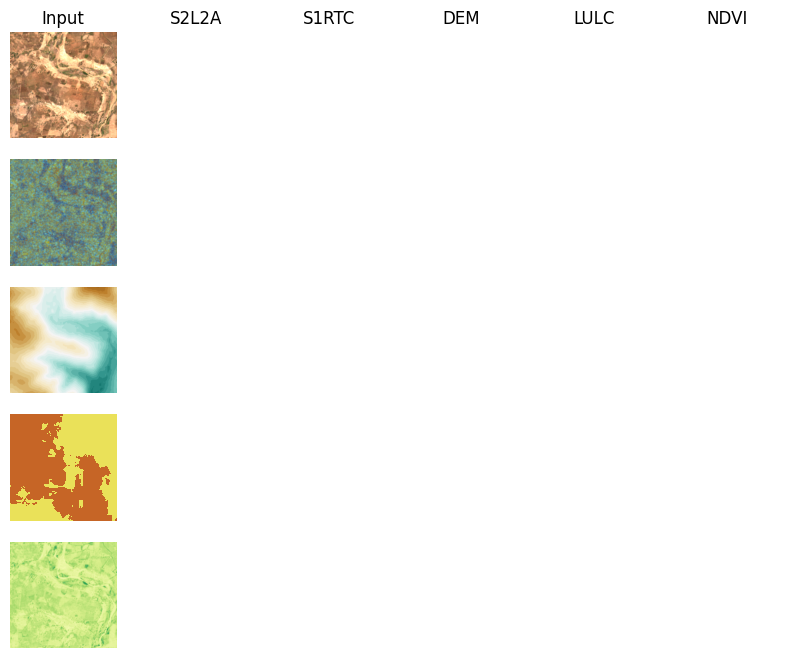

In [4]:
%%time
# Plot any-to-any generations
n_mod = len(modalities)
fig, axes = plt.subplots(nrows=n_mod, ncols=n_mod + 1, figsize=[10, 8])

# Set titles for the top row
axes[0][0].set_title('Input')
for i, m in enumerate(modalities):
    axes[0][i + 1].set_title(m)

# Plot inputs
for (m, input), ax in zip(data.items(), axes):
    plot_modality(m, input, ax=ax[0])  # first column is the input
    for a in ax:
        a.axis('off')

# Plot generated outputs
for k, m_output in enumerate(outputs.values()):
    for m, out in m_output.items():        
        j = modalities.index(m) + 1  # output columns start at index 1
        plot_modality(m, out, ax=axes[k][j])

# Save as PNG to avoid PDF memory spike
plt.tight_layout()
plt.savefig(f'any_to_any_{os.path.basename(file)}.png', dpi=150, bbox_inches='tight')

plt.close(fig)  # Clear from memory to avoid crash

In [ ]:
%%time
# Run any-to-any generation (this can take a while without a GPU, consider reducing timesteps for faster inference)
outputs = {}
for m in modalities:
    print(f'Processing {m}')
    out_modalities = modalities[:]
    out_modalities.remove(m)
    
    # Init model
    model = FULL_MODEL_REGISTRY.build(
        'terramind_v1_base_generate',
        modalities=[m],
        output_modalities=out_modalities,
        pretrained=True,
        standardize=True,
    )
    _ = model.to(device)
    
    input = data[m].clone().to(device)
    with torch.no_grad():
      generated = model(input, verbose=True, timesteps=10)
    outputs[m] = generated

Processing S2L2A


In [1]:
%%time
# Plot any-to-any generations
n_mod = len(modalities)
fig, axes = plt.subplots(nrows=n_mod, ncols=n_mod + 1, figsize=[12, 10])
axes[0][0].set_title('Input')
for i, m in enumerate(modalities):
    axes[0][i + 1].set_title(m)

for (m, input), ax in zip(data.items(), axes):
    plot_modality(m, input, ax=ax[0])
    for a in ax:
        a.axis('off')

for k, m_output in enumerate(outputs.values()):
    for m, out in m_output.items():        
        j = modalities.index(m) + 1
        plot_modality(m, out, ax=axes[k][j])
        
plt.savefig(f'any_to_any_{os.path.basename(file)}.pdf')
plt.show()

NameError: name 'modalities' is not defined